In [2]:
import pandas as pd
import scanpy as sc
import numpy as np
from scipy.stats import median_abs_deviation
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import SpectralBiclustering
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns



# Učitavanje podataka, preprocesiranje i vizualizacija

In [ ]:
osoba1 = pd.read_csv("GSM2230757_human1_umifm_counts.csv.gz", compression="gzip")
osoba2 = pd.read_csv("GSM2230758_human2_umifm_counts.csv.gz", compression="gzip")
osoba3 = pd.read_csv("GSM2230759_human3_umifm_counts.csv.gz", compression="gzip")
osoba4 = pd.read_csv("GSM2230760_human4_umifm_counts.csv.gz", compression="gzip")

metadata_kol = ["Unnamed: 0", "barcode", "assigned_cluster"]
gen_kol = osoba1.columns.difference(metadata_kol)
X = osoba1[gen_kol].values
osoba1_adata = sc.AnnData(X)
# ćelijski metadata
osoba1_adata.obs = osoba1[metadata_kol].copy()
# imena ćelija
osoba1_adata.obs_names = osoba1["barcode"].astype(str)
# imena gena
osoba1_adata.var_names = gen_kol

metadata_kol = ["Unnamed: 0", "barcode", "assigned_cluster"]
gen_kol = osoba2.columns.difference(metadata_kol)
X = osoba2[gen_kol].values
osoba2_adata = sc.AnnData(X)
osoba2_adata.obs = osoba2[metadata_kol].copy()
osoba2_adata.obs_names = osoba2["barcode"].astype(str)
osoba2_adata.var_names = gen_kol

metadata_kol = ["Unnamed: 0", "barcode", "assigned_cluster"]
gen_kol = osoba3.columns.difference(metadata_kol)
X = osoba3[gen_kol].values
osoba3_adata = sc.AnnData(X)
osoba3_adata.obs = osoba3[metadata_kol].copy()
osoba3_adata.obs_names = osoba3["barcode"].astype(str)
osoba3_adata.var_names = gen_kol

metadata_kol = ["Unnamed: 0", "barcode", "assigned_cluster"]
gen_kol = osoba4.columns.difference(metadata_kol)
X = osoba4[gen_kol].values
osoba4_adata = sc.AnnData(X)
osoba4_adata.obs = osoba4[metadata_kol].copy()
osoba4_adata.obs_names = osoba4["barcode"].astype(str)
osoba4_adata.var_names = gen_kol


Index(['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT', 'AA06', 'AAAS',
       'AACS', 'AACSP1', 'AADAC', 'AADACL2', 'AADACL3', 'AADACP1', 'AADAT',
       'AAED1', 'AAGAB', 'AAK1', 'AAMDC', 'AAMP', 'AANAT', 'AAR2', 'AARD',
       'AARS', 'AARS2', 'AARSD1', 'AASDH', 'AASDHPPT', 'AASS', 'AATBC', 'AATF',
       'AATK', 'ABAT', 'ABCA1', 'ABCA10', 'ABCA11P', 'ABCA12', 'ABCA13',
       'ABCA17P', 'ABCA2', 'ABCA3', 'ABCA4', 'ABCA5', 'ABCA6', 'ABCA7',
       'ABCA8', 'ABCA9', 'ABCB1', 'ABCB10', 'ABCB11'],
      dtype='object')


/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


## Filtriranje ćelija lošeg kvaliteta

In [11]:
osoba1_adata.var["mt"] = osoba1_adata.var_names.str.startswith("MT-") 
osoba2_adata.var["mt"] = osoba2_adata.var_names.str.startswith("MT-")
osoba3_adata.var["mt"] = osoba3_adata.var_names.str.startswith("MT-") 
osoba4_adata.var["mt"] = osoba4_adata.var_names.str.startswith("MT-") 
osoba1_adata.var["ribo"] = osoba1_adata.var_names.str.startswith(("RPS", "RPL")) 
osoba2_adata.var["ribo"] = osoba2_adata.var_names.str.startswith(("RPS", "RPL")) 
osoba3_adata.var["ribo"] = osoba3_adata.var_names.str.startswith(("RPS", "RPL")) 
osoba4_adata.var["ribo"] = osoba4_adata.var_names.str.startswith(("RPS", "RPL")) 
osoba1_adata.var["hb"] = osoba1_adata.var_names.str.contains("^HB[^(P)]") 
osoba2_adata.var["hb"] = osoba2_adata.var_names.str.contains("^HB[^(P)]") 
osoba3_adata.var["hb"] = osoba3_adata.var_names.str.contains("^HB[^(P)]") 
osoba4_adata.var["hb"] = osoba4_adata.var_names.str.contains("^HB[^(P)]")

In [12]:
sc.pp.calculate_qc_metrics(
    osoba1_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
sc.pp.calculate_qc_metrics(
    osoba2_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
sc.pp.calculate_qc_metrics(
    osoba3_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
sc.pp.calculate_qc_metrics(
    osoba4_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

In [13]:
for i, ad in enumerate([osoba1_adata, osoba2_adata, osoba3_adata, osoba4_adata], start=1):
    print(f"\n--- osoba{i} ---")
    print("n_genes:", ad.n_vars)
    print("mt genes:", int(ad.var["mt"].sum()))
    print("ribo genes:", int(ad.var["ribo"].sum()))
    print("hb genes:", int(ad.var["hb"].sum()))


--- osoba1 ---
n_genes: 20125
mt genes: 0
ribo genes: 111
hb genes: 13

--- osoba2 ---
n_genes: 20125
mt genes: 0
ribo genes: 111
hb genes: 13

--- osoba3 ---
n_genes: 20125
mt genes: 0
ribo genes: 111
hb genes: 13

--- osoba4 ---
n_genes: 20125
mt genes: 0
ribo genes: 111
hb genes: 13


In [14]:
qc_cols = ["total_counts", "n_genes_by_counts", "pct_counts_mt", "pct_counts_in_top_20_genes"]

for i, ad in enumerate([osoba1_adata, osoba2_adata, osoba3_adata, osoba4_adata], start=1):
    print(f"\n=== osoba{i} QC summary ===")
    print(ad.obs[qc_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


=== osoba1 QC summary ===
       total_counts  n_genes_by_counts  pct_counts_mt  \
count   1937.000000        1937.000000         1937.0   
mean    5805.230253        1923.822922            0.0   
std     3261.436974         652.405717            0.0   
min     1303.000000         819.000000            0.0   
1%      1618.360000         873.720000            0.0   
5%      1937.200000         953.600000            0.0   
50%     5346.000000        1881.000000            0.0   
95%    11249.800000        3082.800000            0.0   
99%    18019.000000        3666.280000            0.0   
max    32472.000000        4903.000000            0.0   

       pct_counts_in_top_20_genes  
count                 1937.000000  
mean                    27.700961  
std                     11.384384  
min                      8.219761  
1%                       9.517552  
5%                      10.770517  
50%                     28.196228  
95%                     47.280932  
99%                  

In [18]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

osoba1_adata.obs["outlier"] = (
    is_outlier(osoba1_adata, "log1p_total_counts", 5)
    | is_outlier(osoba1_adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(osoba1_adata, "pct_counts_in_top_20_genes", 5)
)

osoba2_adata.obs["outlier"] = (
    is_outlier(osoba2_adata, "log1p_total_counts", 5)
    | is_outlier(osoba2_adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(osoba2_adata, "pct_counts_in_top_20_genes", 5)
)

osoba3_adata.obs["outlier"] = (
    is_outlier(osoba3_adata, "log1p_total_counts", 5)
    | is_outlier(osoba3_adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(osoba3_adata, "pct_counts_in_top_20_genes", 5)
)

osoba4_adata.obs["outlier"] = (
    is_outlier(osoba4_adata, "log1p_total_counts", 5)
    | is_outlier(osoba4_adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(osoba4_adata, "pct_counts_in_top_20_genes", 5)
)

osoba1_adata.obs.outlier.value_counts(),osoba2_adata.obs.outlier.value_counts(), osoba3_adata.obs.outlier.value_counts(), osoba4_adata.obs.outlier.value_counts()

(outlier
 False    1936
 True        1
 Name: count, dtype: int64,
 outlier
 False    1723
 True        1
 Name: count, dtype: int64,
 outlier
 False    3598
 True        7
 Name: count, dtype: int64,
 outlier
 False    1298
 True        5
 Name: count, dtype: int64)

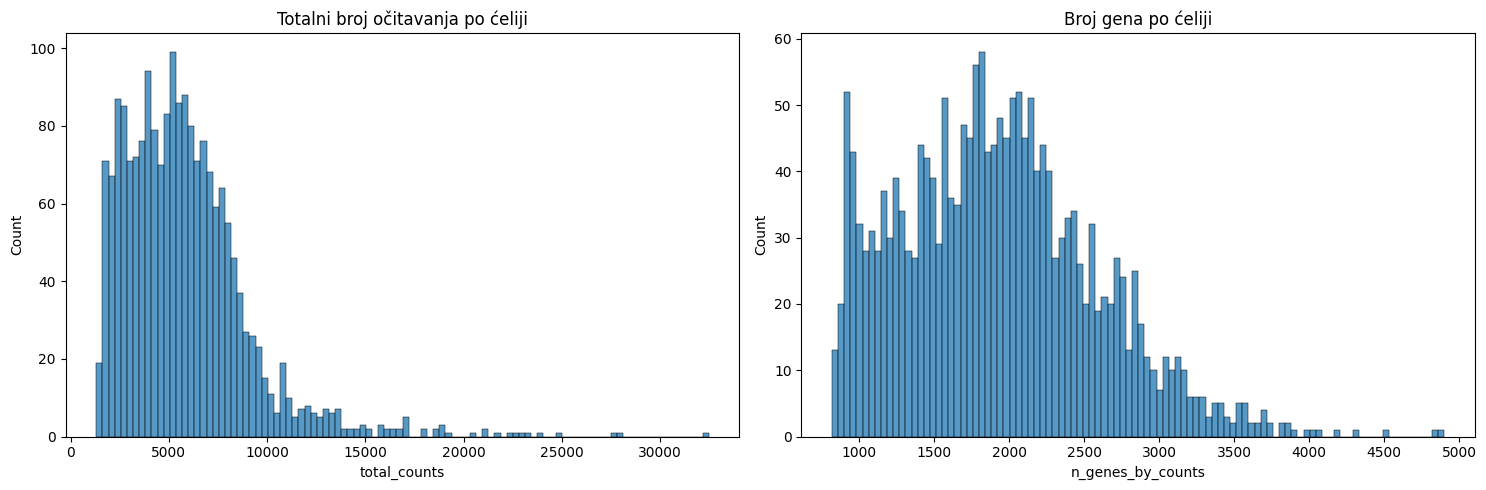

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(osoba1_adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Totalni broj očitavanja po ćeliji")
sns.histplot(osoba1_adata.obs["n_genes_by_counts"], bins=100, kde=False, ax=axes[1])
axes[1].set_title("Broj gena po ćeliji")
plt.tight_layout()
plt.show()


In [ ]:
adata = sc.concat([osoba1_adata, osoba2_adata, osoba3_adata, osoba4_adata], 
                  label="batch", 
                  keys=["H1", "H2", "H3", "H4"])
# Spajanje svih uzoraka u jedan AnnData objekat, sa oznakom batch-a (osobe) u obs koloni "batch"


/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Normalizacija

In [ ]:
adata.layers["counts"] = adata.X.copy()   #Sirovi UMI counts
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy() #Sačuvaj normalizovane podatke pre daljih transformacija

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Selekcija informativnih gena

In [22]:
sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=4000, 
    flavor="seurat", 
    batch_key="batch"
) #Odabir 4000 HVG-a koristeći Seurat metodu, uz korekciju po batch-u (osoba)

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
 

## Redukcija dimenzionalnosti i vizualizacija

/tmp/ipykernel_297623/244058987.py:1: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)#Ponovo izračunaj QC metrike na normalizovanim podacima, koristeći sirove counts iz "counts" layer-a


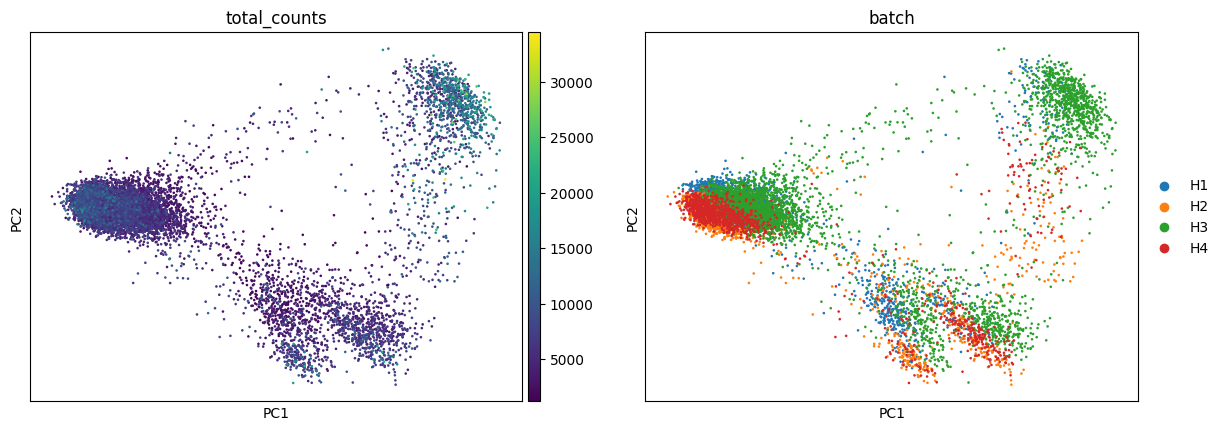

In [ ]:
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)
sc.pl.pca_scatter(adata, color=["total_counts", "batch"])

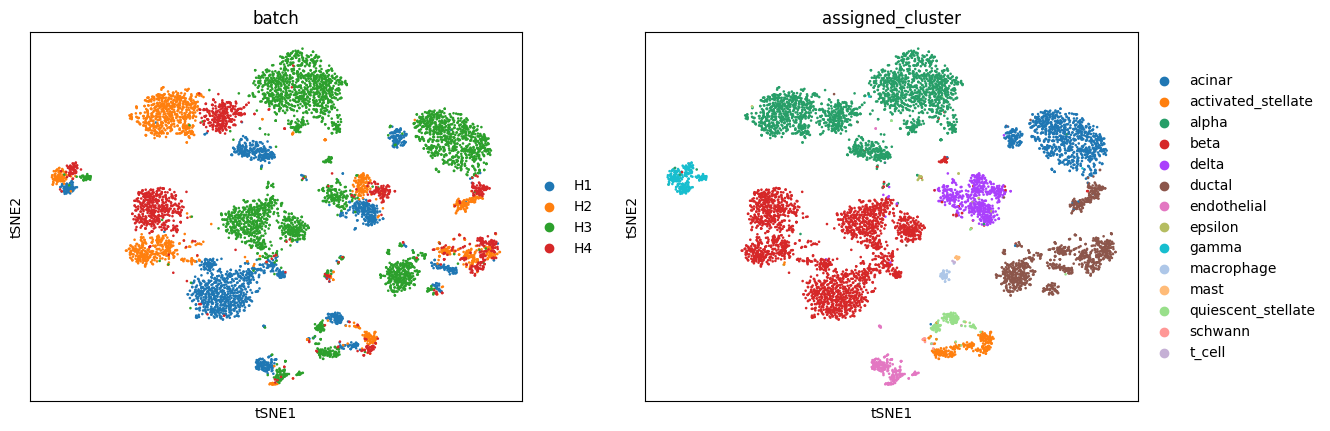

In [27]:
sc.tl.tsne(adata, use_rep="X_pca")
sc.pl.tsne(adata, color=["batch", "assigned_cluster"])

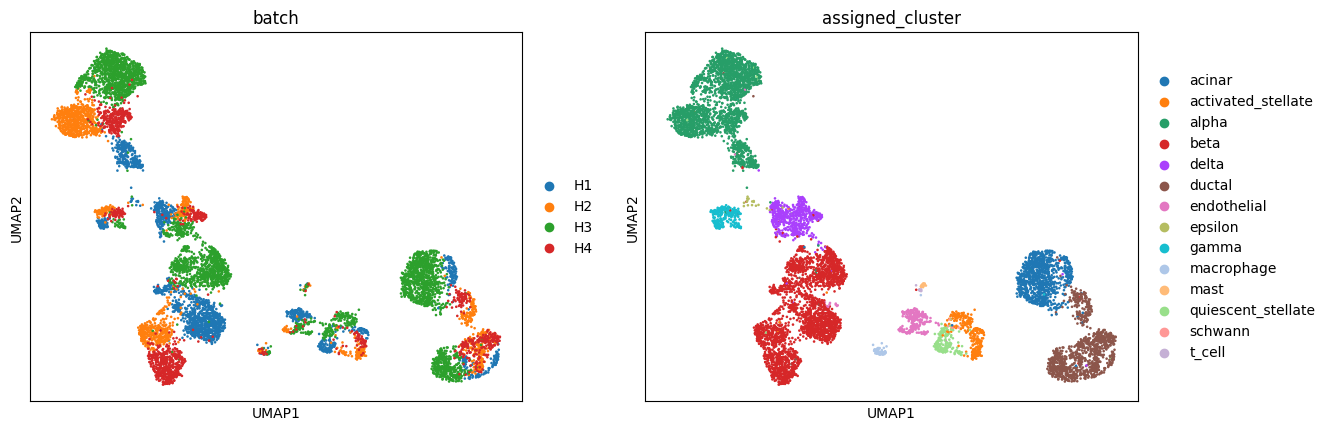

In [28]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["batch", "assigned_cluster"])

# Pravila pridruživanja

In [16]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from itertools import combinations
from scipy.stats import chi2_contingency

In [ ]:
adata.var["hvg_4000"] = adata.var.get("highly_variable", False) #Cuvam informaciju o HVG-ovima u var dataframe-u

sc.pp.highly_variable_genes(adata, n_top_genes=100, flavor="seurat", batch_key="batch")
adata.var["hvg_100"] = adata.var["highly_variable"].copy()
hvgs = adata.var["hvg_100"].values

X = adata[:, hvgs].layers["counts"]  # umesto .X, vraćam se na layer sa sirovim brojevima
X_bin = (X > 0).astype(int)

# ako je sparse:
if hasattr(X_bin, "toarray"):
    X_bin = X_bin.toarray()

df = pd.DataFrame(X_bin, columns=adata.var_names[hvgs])

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
 

In [27]:
frequent_ap = apriori(df, min_support=0.01, use_colnames=True, max_len=2)
rules_ap = association_rules(frequent_ap, metric="lift", min_threshold=1.0)
print("Apriori rules:", rules_ap.head())

if not rules_ap.empty:
    rules_ap["gene1"] = rules_ap["antecedents"].apply(lambda x: list(x)[0])
    rules_ap["gene2"] = rules_ap["consequents"].apply(lambda x: list(x)[0])
    ap_net = rules_ap[["gene1", "gene2", "lift"]].copy()
    ap_net["method"] = "Apriori"
    ap_net.rename(columns={"lift": "score"}, inplace=True)
else:
    ap_net = pd.DataFrame(columns=["gene1","gene2","score","method"])


Apriori rules:   antecedents consequents  antecedent support  consequent support   support  \
0      (CD74)      (ACP5)            0.167972            0.037756  0.012975   
1      (ACP5)      (CD74)            0.037756            0.167972  0.012975   
2      (ACP5)     (HMOX1)            0.037756            0.097253  0.012507   
3     (HMOX1)      (ACP5)            0.097253            0.037756  0.012507   
4      (ACP5)      (PLAU)            0.037756            0.122268  0.012274   

   confidence      lift  representativity  leverage  conviction  \
0    0.077244  2.045897               1.0  0.006633    1.042794   
1    0.343653  2.045897               1.0  0.006633    1.267665   
2    0.331269  3.406261               1.0  0.008835    1.349941   
3    0.128606  3.406261               1.0  0.008835    1.104258   
4    0.325077  2.658735               1.0  0.007657    1.300493   

   zhangs_metric   jaccard  certainty  kulczynski  
0       0.614423  0.067314   0.041038    0.210449  
1  

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [ ]:

frequent_fp = fpgrowth(df, min_support=0.01, use_colnames=True, max_len=2)
rules_fp = association_rules(frequent_fp, metric="lift", min_threshold=1.0)
print("FP-Growth rules:", rules_fp.head())

if not rules_fp.empty:
    rules_fp["gene1"] = rules_fp["antecedents"].apply(lambda x: list(x)[0])
    rules_fp["gene2"] = rules_fp["consequents"].apply(lambda x: list(x)[0])
    fp_net = rules_fp[["gene1", "gene2", "lift"]].copy()
    fp_net["method"] = "FP-Growth"
    fp_net.rename(columns={"lift": "score"}, inplace=True)
else:
    fp_net = pd.DataFrame(columns=["gene1","gene2","score","method"])

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


FP-Growth rules:   antecedents consequents  antecedent support  consequent support   support  \
0     (REG3A)     (PNLIP)            0.118761            0.157802  0.057978   
1     (PNLIP)     (REG3A)            0.157802            0.118761  0.057978   
2      (MT1X)     (REG3A)            0.134775            0.118761  0.021508   
3     (REG3A)      (MT1X)            0.118761            0.134775  0.021508   
4      (G0S2)     (REG3A)            0.148101            0.118761  0.036470   

   confidence      lift  representativity  leverage  conviction  \
0    0.488189  3.093672               1.0  0.039237    1.645524   
1    0.367407  3.093672               1.0  0.039237    1.393059   
2    0.159584  1.343739               1.0  0.005502    1.048574   
3    0.181102  1.343739               1.0  0.005502    1.056573   
4    0.246251  2.073501               1.0  0.018881    1.169141   

   zhangs_metric   jaccard  certainty  kulczynski  
0       0.767964  0.265241   0.392291    0.427798  
1

In [29]:
def eclat_pairwise(df, min_support=0.01):
    n = df.shape[0]
    results = []
    cols = df.columns
    for a, b in combinations(cols, 2):
        support = np.sum(df[a] & df[b]) / n
        if support >= min_support:
            results.append((a, b, support))
    return pd.DataFrame(results, columns=["gene1", "gene2", "score"])

eclat_net = eclat_pairwise(df, min_support=0.02)
eclat_net["method"] = "Eclat"
print("Eclat pairwise rules:", eclat_net.head())

Eclat pairwise rules:   gene1  gene2     score method
0   ALB   G0S2  0.028989  Eclat
1   ALB  PNLIP  0.054939  Eclat
2   ALB  REG3A  0.032145  Eclat
3   ALB  REG3G  0.038925  Eclat
4  CD74   CTGF  0.031093  Eclat


In [30]:
corr_matrix = df.corr()
pairs = np.where(np.triu(corr_matrix.values, k=1) > 0.2)

corr_net = pd.DataFrame({
    "gene1": df.columns[pairs[0]],
    "gene2": df.columns[pairs[1]],
    "score": corr_matrix.values[pairs]
})
corr_net["method"] = "Correlation"
print("Correlation rules:", corr_net.head())


Correlation rules:   gene1    gene2     score       method
0  ACP5     APOE  0.224511  Correlation
1  ACP5     C1QA  0.316239  Correlation
2  ACP5     C1QB  0.317181  Correlation
3  ACP5     C1QC  0.358786  Correlation
4  ACP5  HLA-DRA  0.220373  Correlation


In [31]:
def chi2_pairwise(df, p_threshold=0.01):
    results = []
    cols = df.columns
    for a, b in combinations(cols, 2):
        table = pd.crosstab(df[a], df[b])
        chi2, p, _, _ = chi2_contingency(table)
        if p < p_threshold:
            results.append((a, b, -np.log10(p)))
    return pd.DataFrame(results, columns=["gene1","gene2","score"])

chi2_net = chi2_pairwise(df.iloc[:, :200], p_threshold=0.01)
chi2_net["method"] = "Chi-square"
print("Chi-square rules:", chi2_net.head())

/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  results.append((a, b, -np.log10(p)))
/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  results.append((a, b, -np.log10(p)))
/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  results.append((a, b, -np.log10(p)))
/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  results.append((a, b, -np.log10(p)))
/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  results.append((a, b, -np.log10(p)))
/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  results.append((a, b, -np.log10(p)))
/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  results.append((a, b, -np.log10(p)))
/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  resul

Chi-square rules:   gene1  gene2       score      method
0  ACP5   APOE   93.343905  Chi-square
1  ACP5   C1QA  182.394260  Chi-square
2  ACP5   C1QB  183.916655  Chi-square
3  ACP5   C1QC  235.365167  Chi-square
4  ACP5  CCL18   40.618857  Chi-square


/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  results.append((a, b, -np.log10(p)))
/tmp/ipykernel_18407/2294697038.py:8: RuntimeWarning: divide by zero encountered in log10
  results.append((a, b, -np.log10(p)))


In [36]:
def plot_rules(df, method_name, top_n=20):
    
    # uzmi samo jednu metodu
    data = df[df["method"] == method_name].copy()
    
    if data.empty:
        print(f"No rules for {method_name}")
        return
    
    # uzmi najjača pravila
    data = data.sort_values("score", ascending=False).head(top_n)
    
    # normalizuj score radi lepšeg prikaza
    score_norm = (data["score"] - data["score"].min()) / \
                 (data["score"].max() - data["score"].min() + 1e-9)
    
    plt.figure(figsize=(8,6))
    
    scatter = plt.scatter(
        data["gene1"],
        data["gene2"],
        s=score_norm * 800 + 50,
        c=score_norm,
        cmap="viridis",
        alpha=0.7
    )
    
    plt.xticks(rotation=90)
    plt.xlabel("Antecedent (Gene1)")
    plt.ylabel("Consequent (Gene2)")
    plt.title(f"{method_name} – Top Association Rules")
    
    cbar = plt.colorbar(scatter)
    cbar.set_label("Normalized Rule Strength")
    
    plt.tight_layout()
    plt.show()


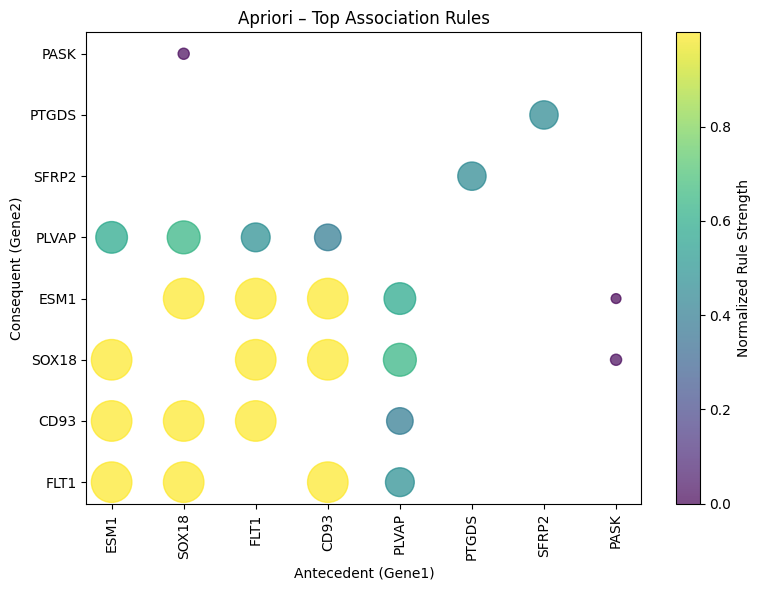

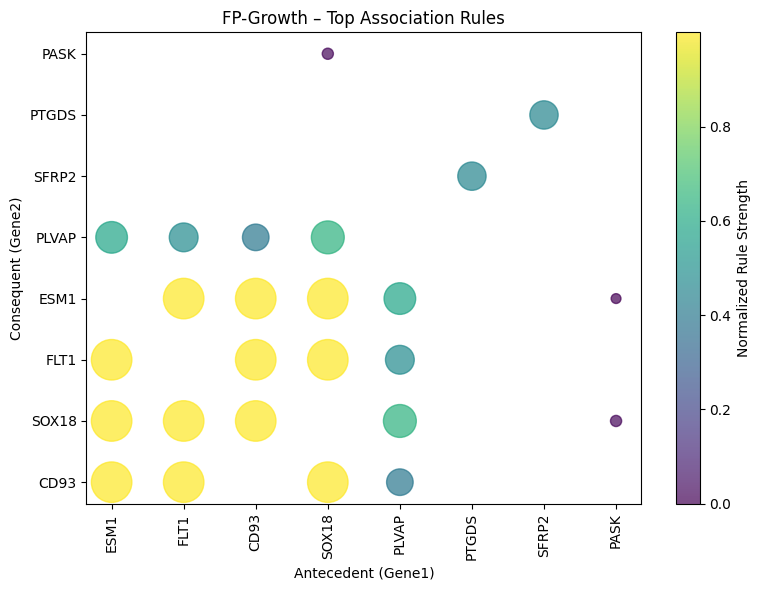

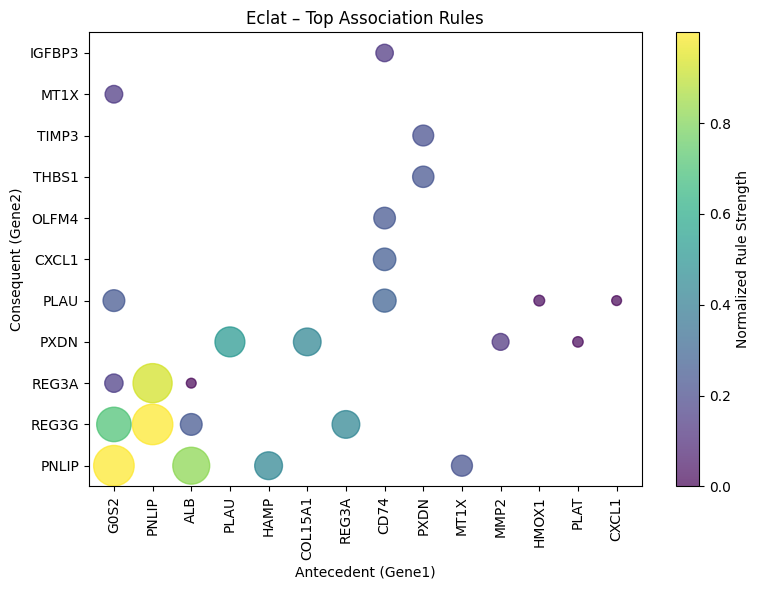

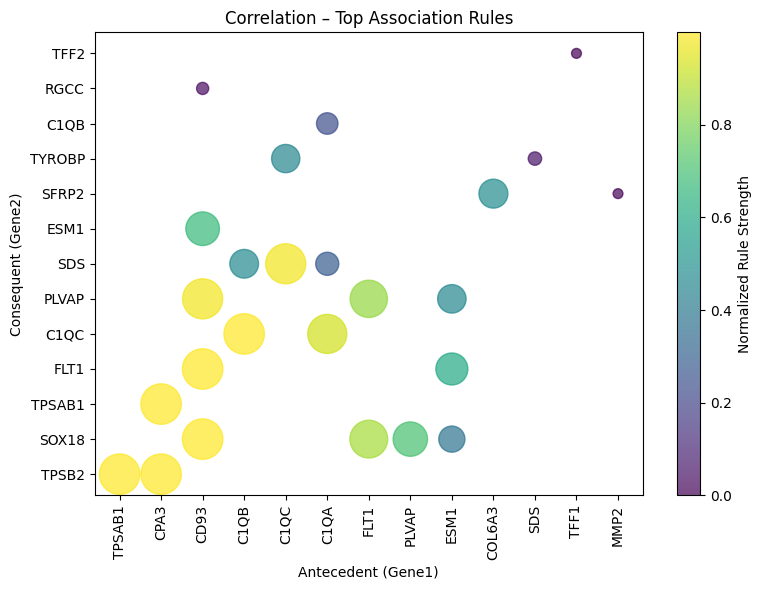

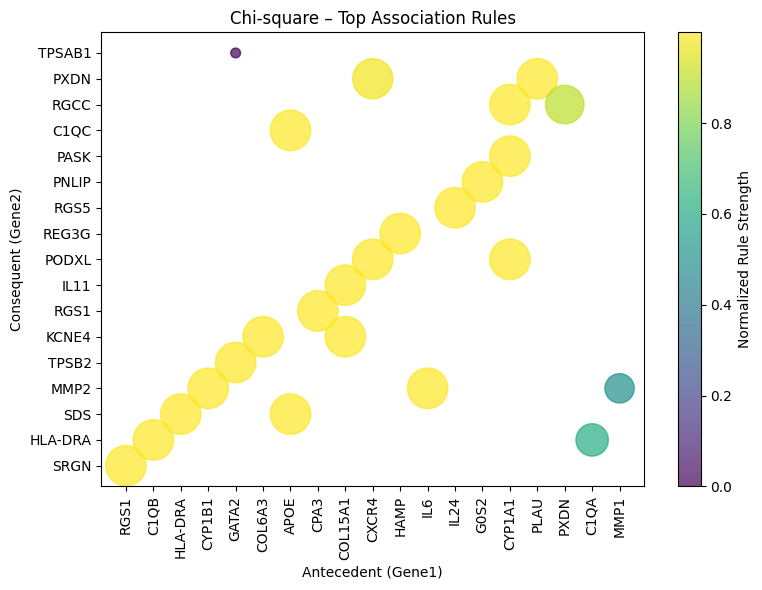

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# -------------------------------------------------
# CLEANING: remove inf and extreme values
# -------------------------------------------------

# ukloni inf
all_edges = all_edges.replace([np.inf, -np.inf], np.nan)
all_edges = all_edges.dropna(subset=["score"])

# opcionalno: ograniči ekstremne vrednosti po metodi
def clip_extreme(x):
    upper = x.quantile(0.99)
    lower = x.quantile(0.01)
    return x.clip(lower, upper)

all_edges["score"] = (
    all_edges.groupby("method")["score"]
    .transform(clip_extreme)
)

scaler = MinMaxScaler()

def normalize_group(x):
    return scaler.fit_transform(x.values.reshape(-1,1)).flatten()

all_edges["score_norm"] = (
    all_edges.groupby("method")["score"]
    .transform(normalize_group)
)

for m in all_edges["method"].unique():
    plot_rules(all_edges, m, top_n=25)


# Klasterovanje

In scRNA-seq data analysis, we describe cellular structure in our dataset with finding cell identities that relate to known cell states or cell cycle stages. This process is usually called cell identity annotation. For this purpose, we structure cells into clusters to infer the identity of similar cells

UKLONITI ARI METRIKU JER CU KASNIJE SVAKAKO RADITI KLASIFIKACIJU NA OSNOVU ASSIGNED KLASTER

## K-means klasterizacija

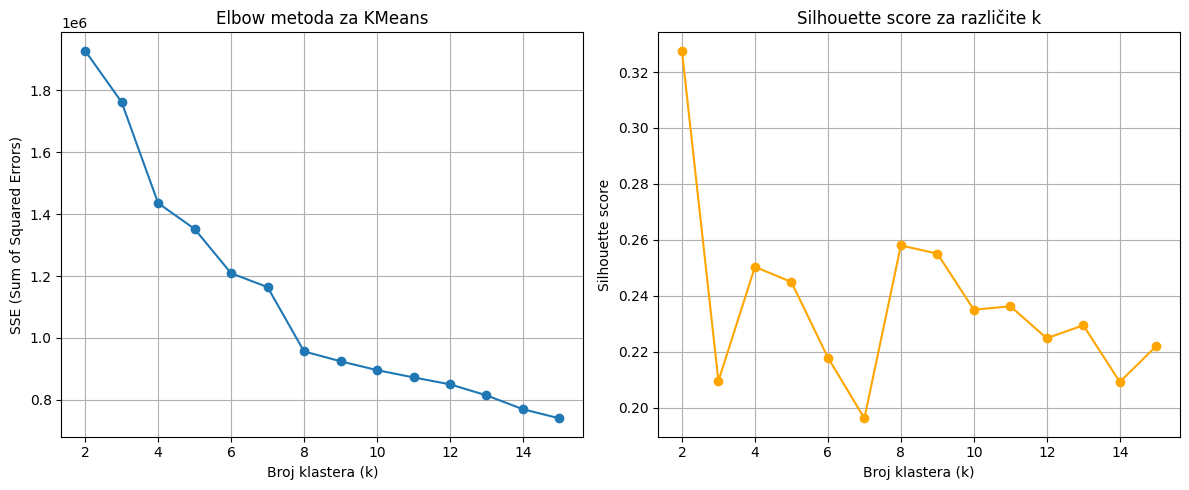

In [37]:
from sklearn.cluster import KMeans

X = adata.obsm['X_pca']

# 1. Elbow metoda i SSE za k = 2 do 15
sse = []
silhouette_scores = []
K_range = range(2, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sse.append(kmeans.inertia_)  # SSE = sum of squared distances to cluster centers
    silhouette_scores.append(silhouette_score(X, labels))

# Grafički prikaz SSE (Elbow metoda)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K_range, sse, marker='o')
plt.xlabel("Broj klastera (k)")
plt.ylabel("SSE (Sum of Squared Errors)")
plt.title("Elbow metoda za KMeans")
plt.grid(True)

# Grafički prikaz Silhouette score
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.xlabel("Broj klastera (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score za različite k")
plt.grid(True)

plt.tight_layout()
plt.show()


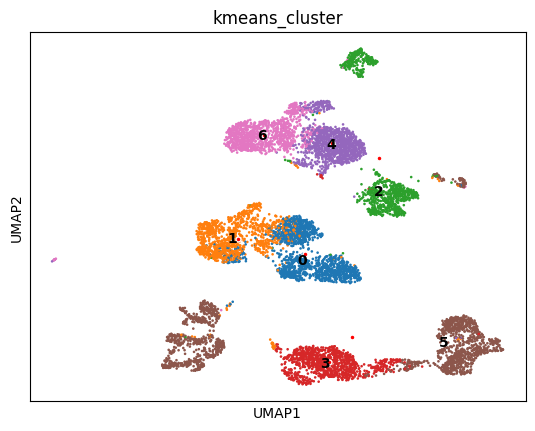

In [38]:
# 1. Priprema suseda i UMAP-a (ovo ti je verovatno falilo)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

# 2. KMeans na PCA
kmeans = KMeans(n_clusters=7, random_state=42)
adata.obs['kmeans_cluster'] = kmeans.fit_predict(adata.obsm['X_pca']).astype(str)

# 3. Izvlačenje koordinata za centroide
# Napomena: adata.obsm['X_umap'] sada postoji jer smo ga gore izračunali
umap_coords = pd.DataFrame(adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
umap_coords['cluster'] = adata.obs['kmeans_cluster'].values
centroids_umap = umap_coords.groupby('cluster').mean()

# 4. Vizualizacija
ax = sc.pl.umap(adata, color=['kmeans_cluster'], show=False, legend_loc="on data")
plt.scatter(centroids_umap['UMAP1'], centroids_umap['UMAP2'], 
            c='red', s=50, marker='.', edgecolors='white', label='Centroidi')
plt.show()

## Leiden algoritam (Algoritam zasnovan na grafu/gustini)

Teorijska veza: Moderna verzija detekcije zajednica u KNN grafu (povezuje se sa DBSCAN logikom gustine i povezanosti).

Implementacija: Koristimo sc.tl.leiden.

The Leiden algorithm is an improved version of the Louvain algorithm which outperformed other clustering methods for single-cell RNA-seq data analysis ([Du et al., 2018, Freytag et al., 2018, Weber and Robinson, 2016]). Since the Louvain algorithm is no longer maintained, using Leiden instead is preferred.

We, therefore, propose to use the Leiden algorithm[Traag et al., 2019] on single-cell k-nearest-neighbour (KNN) graphs to cluster single-cell datasets.

Leiden creates clusters by taking into account the number of links between cells in a cluster versus the overall expected number of links in the dataset.

The starting point is a singleton partition in which each node functions as its own community (a). As a next step, the algorithm creates partitions by moving individual nodes from one community to another (b), which is refined afterwards to enhance the partitioning (c). The refined partition is then aggregated to a network (d). Subsequently, the algorithm moves again individual nodes in the aggregate network (e), until refinement does no longer change the partition (f). All steps are repeated until the final clustering is created and partitions no longer change.

The Leiden module has a resolution parameter which allows to determine the scale of the partition cluster and therefore the coarseness of the clustering. A higher resolution parameter leads to more clusters. The algorithm additionally allows efficient sub-clustering of particular clusters in the dataset by sub-setting the KNN graph. Sub-clustering enables the user to identify cell-type specific states within clusters or a finer cell type labeling[Wagner et al., 2016], but can also lead to patterns that are only due to noise present in the data.

The Leiden algorithm leverages a KNN graph on the reduced expression space. We can calculate the KNN graph on a lower-dimensional gene expression representation with the scanpy function sc.pp.neighbors. We call this function on the top 30 principal-components as these capture most of the variance in the dataset.


In [39]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca")
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25, random_state= 42)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5, random_state= 42)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0, random_state= 42)

/tmp/ipykernel_104685/2266908139.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25, random_state= 42)
/tmp/ipykernel_104685/2266908139.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_a

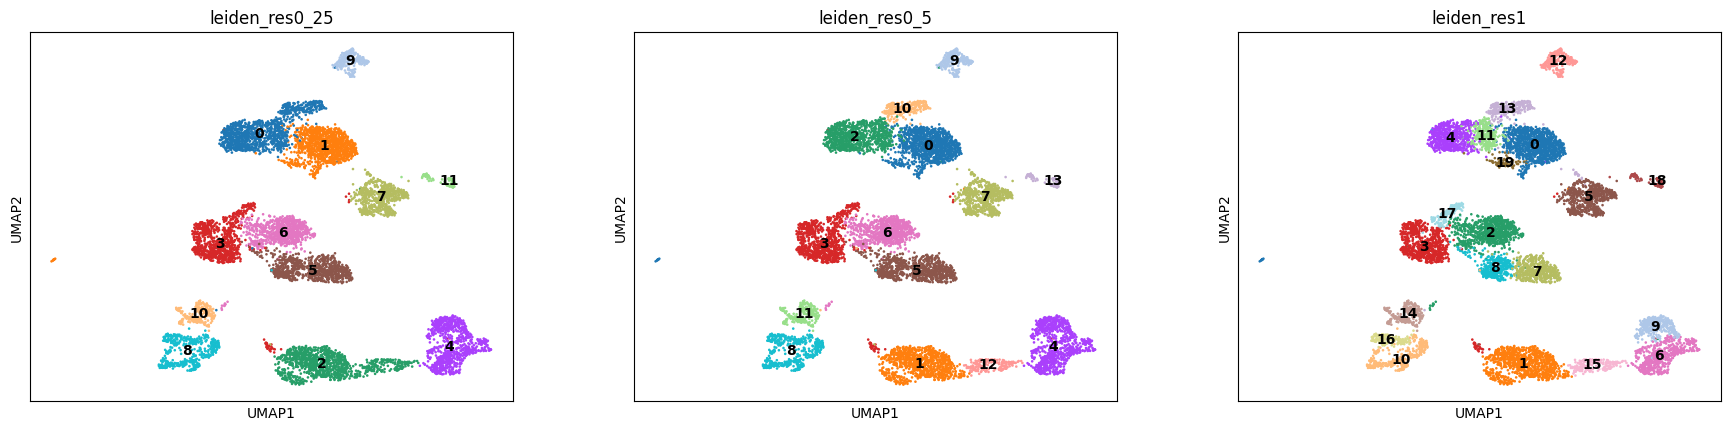

In [40]:
sc.pl.umap(
    adata,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
)

In [41]:
# Uzmi embedding koji si koristila za neighbors (npr. PCA)
X = adata.obsm["X_pca"]

# Uzmi labels iz AnnData
labels = adata.obs["leiden_res0_25"]
score = silhouette_score(X, labels)
print("Silhouette score za leiden_res0_25:", score)

labels = adata.obs["leiden_res0_5"]
score = silhouette_score(X, labels)
print("Silhouette score za leiden_res0_5:", score)

labels = adata.obs["leiden_res1"]
score = silhouette_score(X, labels)
print("Silhouette score za leiden_res1:", score)

Silhouette score za leiden_res0_25: 0.2367059588432312
Silhouette score za leiden_res0_5: 0.21347790956497192
Silhouette score za leiden_res1: 0.19273577630519867



## Spectral Clustering
Spektralno klasterovanje koristi sopstvene vektore Laplasijana matrice sličnosti i omogućava identifikaciju nelinearnih struktura koje KMeans ne može da detektuje.


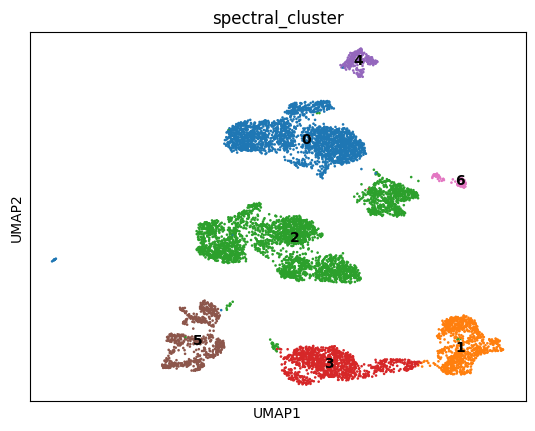

Silhouette score (Spectral): 0.28213417530059814
ARI (Spectral vs assigned_cluster): 0.8222686814425404


In [42]:
X = adata.obsm["X_pca"]

spectral = SpectralClustering(
    n_clusters=7,                # isti broj kao KMeans radi poređenja
    affinity="nearest_neighbors",
    n_neighbors=15,
    random_state=42
)

labels_spectral = spectral.fit_predict(X)

adata.obs["spectral_cluster"] = labels_spectral.astype(str)

# UMAP vizualizacija
sc.pl.umap(adata, color="spectral_cluster", legend_loc="on data")

# Evaluacija
sil_spectral = silhouette_score(X, labels_spectral)
print("Silhouette score (Spectral):", sil_spectral)

ari_spectral = adjusted_rand_score(
    adata.obs["assigned_cluster"], labels_spectral
)
print("ARI (Spectral vs assigned_cluster):", ari_spectral)


## Hieracical

Ovo radimo nad matricom ekspresije (ne PCA).

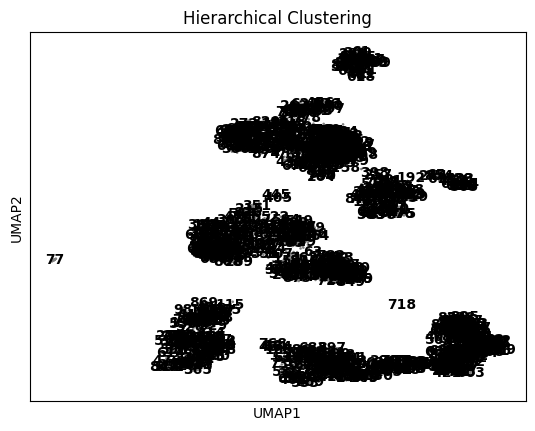

Silhouette score (Hierarchical): 0.05062051862478256


In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Use PCA representation
X = adata.obsm["X_pca"]

hc = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=15,   # tune this value
    linkage="ward"
)

adata.obs["hierarchical"] = hc.fit_predict(X).astype(str)

sil_hc = silhouette_score(X, adata.obs["hierarchical"].astype(int))
print("Silhouette score (Hierarchical):", sil_hc)

Biclustering pretpostavlja blok strukturu gena × ćelija.
Kod scRNA-seq to često nije optimalan model jer ćelije dele gene globalno, a ne u šahovskim blokovima.

Zato često daje slabiji rezultat od Leiden/Spectral.

## Gausian Mixture model

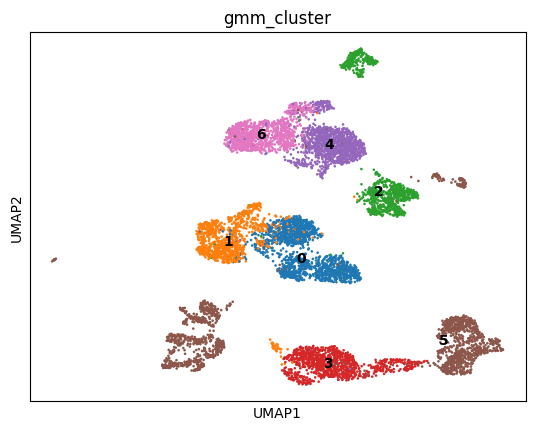

Silhouette score (GMM): 0.18492116034030914


In [44]:
gmm = GaussianMixture(
    n_components=7,
    covariance_type="full",
    random_state=42
)

gmm.fit(X)
labels_gmm = gmm.predict(X)

adata.obs["gmm_cluster"] = labels_gmm.astype(str)

sc.pl.umap(adata, color="gmm_cluster", legend_loc="on data")

# Evaluacija
sil_gmm = silhouette_score(X, labels_gmm)
print("Silhouette score (GMM):", sil_gmm)



## Poređenje

In [45]:
results = pd.DataFrame({
    "Model": ["KMeans", "Leiden (0.25)", "Spectral", "GMM", "Biclustering"],
    "Silhouette": [
        silhouette_score(X, adata.obs["kmeans_cluster"]),
        silhouette_score(X, adata.obs["leiden_res0_25"]),
        sil_spectral,
        sil_gmm,
        sil_hc
    ]
})

print(results)


           Model  Silhouette
0         KMeans    0.196152
1  Leiden (0.25)    0.236706
2       Spectral    0.282134
3            GMM    0.184921
4   Biclustering    0.050621


# Klasifikacija

PROBLEM NEJEDNAKIH KLASA; TREBA DA GA RESIM NEKAKO A NAJBOLJE JE DA GA SVUDA ISTO RESAVAM

Priprema

In [46]:
# PCA embedding
X = adata.obsm["X_pca"]

# target
y = adata.obs["assigned_cluster"].astype(str)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (5988, 50)
Test size: (2567, 50)


## Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.983248928710557
Macro F1: 0.8609122192601405
                    precision    recall  f1-score   support

            acinar       0.99      0.98      0.98       285
activated_stellate       0.98      0.98      0.98        85
             alpha       0.99      1.00      0.99       698
              beta       0.98      0.99      0.99       757
             delta       0.95      0.96      0.96       179
            ductal       0.98      0.99      0.98       323
       endothelial       1.00      0.99      0.99        76
           epsilon       0.00      0.00      0.00         5
             gamma       0.97      0.97      0.97        77
        macrophage       1.00      0.82      0.90        17
              mast       1.00      1.00      1.00         7
quiescent_stellate       0.94      0.94      0.94        52
           schwann       1.00      0.75      0.86         4
            t_cell       0.50      0.50      0.50         2

          accuracy 

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

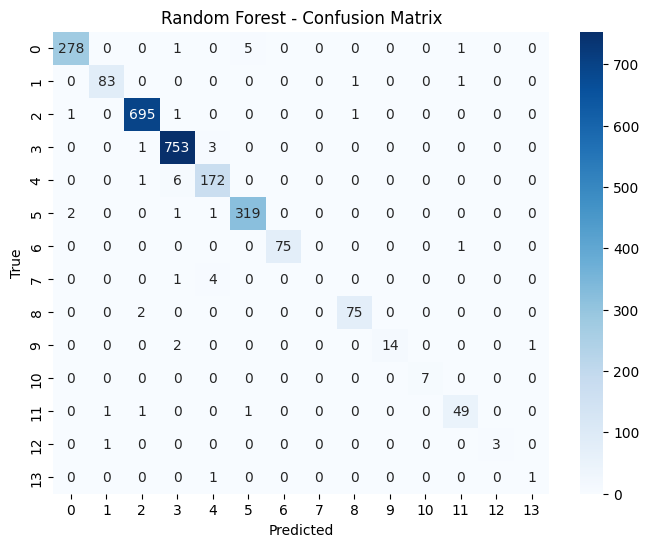

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

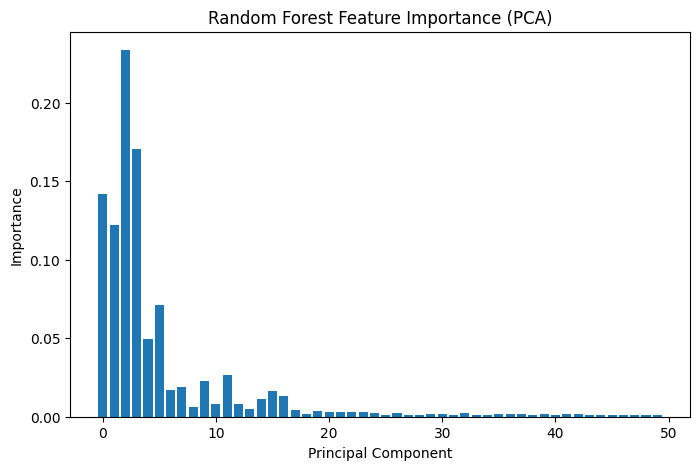

In [49]:
importances_rf = rf.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(range(len(importances_rf)), importances_rf)
plt.title("Random Forest Feature Importance (PCA)")
plt.xlabel("Principal Component")
plt.ylabel("Importance")
plt.show()


## XGBoost 

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [51]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train_enc)),
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train_enc)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBOOST ===")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))
print("Macro F1:", f1_score(y_test_enc, y_pred_xgb, average="macro"))
print(classification_report(y_test_enc, y_pred_xgb))

=== XGBOOST ===
Accuracy: 0.9871445266848461
Macro F1: 0.9620046277577287
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       285
           1       0.99      0.96      0.98        85
           2       1.00      1.00      1.00       698
           3       0.99      0.99      0.99       757
           4       0.98      0.97      0.97       179
           5       0.98      0.98      0.98       323
           6       1.00      0.99      0.99        76
           7       1.00      0.80      0.89         5
           8       0.97      0.99      0.98        77
           9       1.00      1.00      1.00        17
          10       1.00      1.00      1.00         7
          11       0.94      0.96      0.95        52
          12       0.75      0.75      0.75         4
          13       1.00      1.00      1.00         2

    accuracy                           0.99      2567
   macro avg       0.97      0.96      0.96      2567
weight

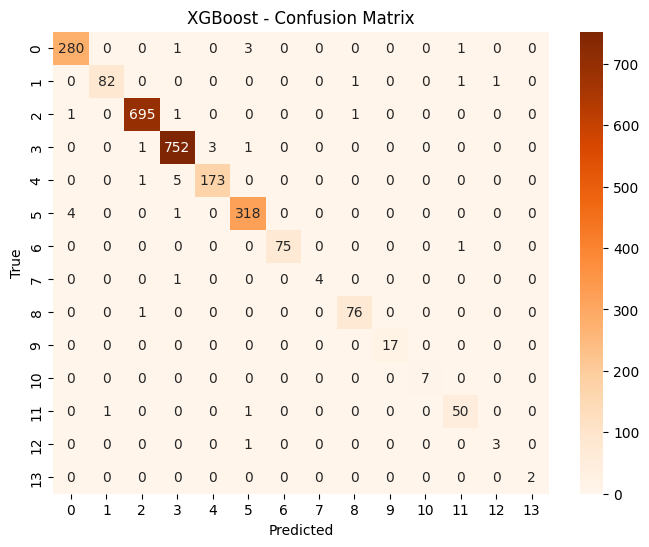

In [52]:
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


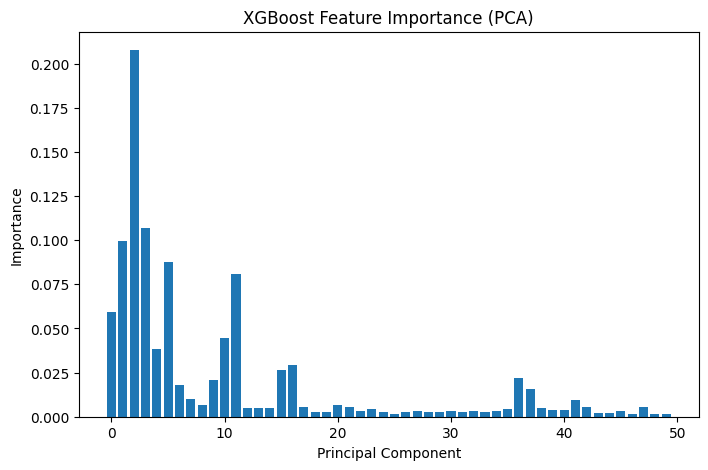

In [53]:
importances_xgb = xgb.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(range(len(importances_xgb)), importances_xgb)
plt.title("XGBoost Feature Importance (PCA)")
plt.xlabel("Principal Component")
plt.ylabel("Importance")
plt.show()


## LightGBM

In [54]:
lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=len(np.unique(y_train_enc)),
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=50,
    min_data_in_leaf=5,
    class_weight="balanced",
    verbose=-1,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train_enc)
y_pred_lgbm = lgbm.predict(X_test)

print("=== LightGBM ===")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_lgbm))
print("Macro F1:", f1_score(y_test_enc, y_pred_lgbm, average="macro"))
print(classification_report(y_test_enc, y_pred_lgbm))   

=== LightGBM ===
Accuracy: 0.9851967276977016
Macro F1: 0.9305991083689242
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       285
           1       0.99      0.96      0.98        85
           2       0.99      0.99      0.99       698
           3       0.99      0.99      0.99       757
           4       0.98      0.97      0.98       179
           5       0.98      0.98      0.98       323
           6       1.00      0.99      0.99        76
           7       0.80      0.80      0.80         5
           8       0.97      0.99      0.98        77
           9       1.00      1.00      1.00        17
          10       1.00      1.00      1.00         7
          11       0.94      0.94      0.94        52
          12       0.75      0.75      0.75         4
          13       1.00      0.50      0.67         2

    accuracy                           0.99      2567
   macro avg       0.96      0.92      0.93      2567
weigh

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


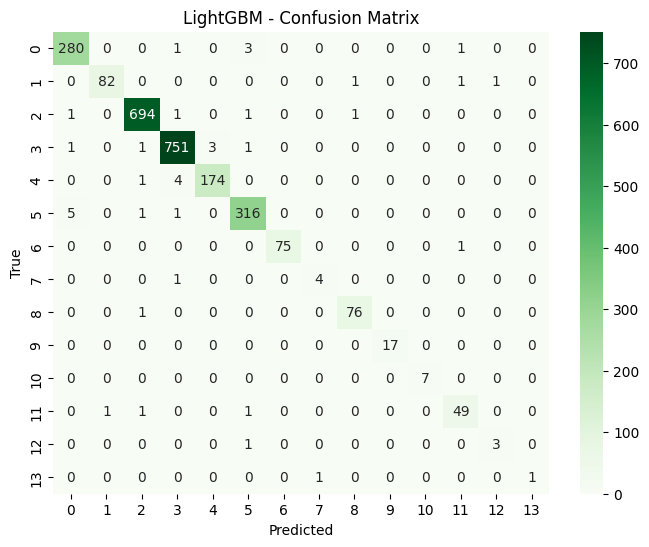

In [55]:
cm_lgbm = confusion_matrix(y_test_enc, y_pred_lgbm)

plt.figure(figsize=(8,6))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Greens")
plt.title("LightGBM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## SVM

In [56]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM F1-score:", f1_score(y_test, y_pred_svm, average="weighted"))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.9883132060771328
SVM F1-score: 0.9881919953749125
                    precision    recall  f1-score   support

            acinar       0.98      0.99      0.98       285
activated_stellate       0.98      0.98      0.98        85
             alpha       0.99      1.00      1.00       698
              beta       0.99      1.00      0.99       757
             delta       0.98      0.97      0.97       179
            ductal       1.00      0.98      0.99       323
       endothelial       1.00      0.99      0.99        76
           epsilon       1.00      0.60      0.75         5
             gamma       0.99      0.99      0.99        77
        macrophage       1.00      0.94      0.97        17
              mast       1.00      1.00      1.00         7
quiescent_stellate       0.94      0.98      0.96        52
           schwann       1.00      0.75      0.86         4
            t_cell       0.50      0.50      0.50         2

          accuracy              

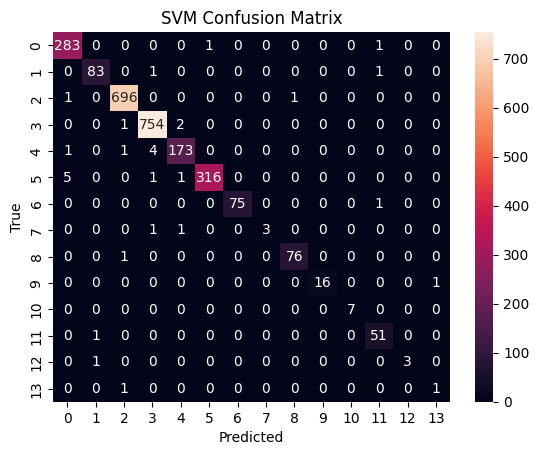

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Naivni Bajes 

In [58]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes F1-score:", f1_score(y_test, y_pred_nb, average="weighted"))
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.9746786131671211
Naive Bayes F1-score: 0.9745620018933323
                    precision    recall  f1-score   support

            acinar       0.99      0.94      0.97       285
activated_stellate       0.98      0.98      0.98        85
             alpha       0.99      0.98      0.99       698
              beta       0.99      0.99      0.99       757
             delta       0.99      0.95      0.97       179
            ductal       0.88      0.99      0.94       323
       endothelial       1.00      0.97      0.99        76
           epsilon       1.00      0.80      0.89         5
             gamma       0.97      1.00      0.99        77
        macrophage       1.00      0.88      0.94        17
              mast       1.00      1.00      1.00         7
quiescent_stellate       0.92      0.94      0.93        52
           schwann       1.00      0.75      0.86         4
            t_cell       0.00      0.00      0.00         2

          accura

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

## Uporedjivanje rezultata

In [61]:

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))
print("XGBoost Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))
print("XGBoost Macro F1:", f1_score(y_test_enc, y_pred_xgb, average="macro"))
print("LightGBM Accuracy:", accuracy_score(y_test_enc, y_pred_lgbm))
print("LightGBM Macro F1:", f1_score(y_test_enc, y_pred_lgbm, average="macro"))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM F1-score:", f1_score(y_test, y_pred_svm, average="weighted"))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes F1-score:", f1_score(y_test, y_pred_nb, average="weighted"))

Random Forest Accuracy: 0.983248928710557
Random Forest Macro F1: 0.8609122192601405
XGBoost Accuracy: 0.9871445266848461
XGBoost Macro F1: 0.9620046277577287
LightGBM Accuracy: 0.9851967276977016
LightGBM Macro F1: 0.9305991083689242
SVM Accuracy: 0.9883132060771328
SVM F1-score: 0.9881919953749125
Naive Bayes Accuracy: 0.9746786131671211
Naive Bayes F1-score: 0.9745620018933323
